In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [5]:
import so as so

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [7]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

# load data

In [8]:
files = os.listdir('./soDGVAE_dataset/dataset/5_development_chicken_heart/')
files

['chiken_heart10d_10xVisium.h5ad',
 'chiken_heart7d_10xVisium.h5ad',
 'chiken_heart14d_10xVisium.h5ad',
 'chiken_heart4d_10xVisium.h5ad',
 '0_statistics.ipynb',
 '.ipynb_checkpoints']

In [9]:
files = [
'chiken_heart4d_10xVisium.h5ad',
'chiken_heart7d_10xVisium.h5ad',
'chiken_heart10d_10xVisium.h5ad',
'chiken_heart14d_10xVisium.h5ad',
]

In [10]:
data_list = [sc.read_h5ad(f'./soDGVAE_dataset/dataset/5_development_chicken_heart/{file}') for file in files]
data_list

[AnnData object with n_obs × n_vars = 747 × 24356
     obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'subregion'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'celltype_prediction_mode_colors', 'region_colors', 'subregion_colors'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 1966 × 24356
     obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn

In [11]:
batch_names = files

In [13]:
data_list[0].obs.loc[:, 'orig.ident'].unique()

['D4']
Categories (1, object): ['D4']

In [12]:
data_list[0].obs

,in_tissue,x,y,x_pixel,y_pixel,orig.ident,nCount_Spatial,nFeature_Spatial,percent.mito,Spatial_snn_res.1,...,TMSB4X.high.cells,Epi-mesenchymal.cells,Dendritic.cells,Mural.cells,max,celltype_prediction_max,celltype_prediction,celltype_prediction_mode,region,subregion
AAACCCGAACGAAATC-1,1,45,115,9375,4140,D4,1406,737,13.726885,14,...,0.015729,0.0,0,0.146417,0.620207,Cardiomyocytes-2,Cardiomyocytes-2,Cardiomyocytes-2,Epicardium,Epicardium- like
AAACCGGAAATGTTAA-1,1,54,124,7200,2892,D4,10539,2635,17.079419,9,...,0.000000,0.0,0,0.000000,0.438508,MT-enriched cardiomyocytes,MT-enriched cardiomyocytes,Immature myocardial cells,Left Ventricle,Ventricle
AAACGAGACGGTTGAT-1,1,35,79,11796,9137,D4,18973,3725,12.760238,9,...,0.016277,0.0,0,0.000000,0.879677,Endocardial cells,Endocardial cells,Endocardial cells,Left Ventricle,Ventricle
AAACGGGCGTACGGGT-1,1,65,91,4546,7477,D4,10977,2617,11.569646,11,...,0.000000,0.0,0,0.000000,0.967304,Valve cells,Valve cells,Valve cells,Outflow/Valves,Valves
AAACTGCTGGCTCCAA-1,1,45,67,9381,10805,D4,3918,1463,14.293007,9,...,0.083486,0.0,0,0.000000,0.374499,Erythrocytes,Endocardial cells,Endocardial cells,Epicardium,Epicardium- like
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGTGAACCTAATCCG-1,1,56,90,6721,7614,D4,4619,1715,12.621780,9,...,0.040612,0.0,0,0.000000,0.467375,Cardiomyocytes-1,Immature myocardial cells,Immature myocardial cells,Left Ventricle,Ventricle
TTGTGGCCCTGACAGT-1,1,18,60,15906,11772,D4,6360,1997,10.157233,11,...,0.000000,0.0,0,0.000000,0.974126,Valve cells,Valve cells,Valve cells,Outflow/Valves,Outflow tract
TTGTGGTGGTACTAAG-1,1,63,95,5029,6921,D4,9031,2547,13.985162,9,...,0.000000,0.0,0,0.000000,0.870082,Immature myocardial cells,Immature myocardial cells,Immature myocardial cells,Outflow/Valves,Outflow tract
TTGTGTTTCCCGAAAG-1,1,51,59,7933,11918,D4,802,481,16.209476,14,...,0.040219,0.0,0,0.041257,0.683699,Cardiomyocytes-2,Cardiomyocytes-2,Cardiomyocytes-2,Epicardium,Epicardium- like


In [13]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=3000, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 6596 × 3000
    obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'subregion', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [14]:
rad_cutoff_list = [0] * len(data_list)
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list, model='KNN')

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 0 edges, 747 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 1966 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 1916 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 1967 cells.
0.0000 neighbors per cell on average.


In [15]:
path_results = f'./log/result/'

In [16]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=500,
                            batch_size=len(adata),
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            alpha_mmd=0,
                            graph_loss=False,
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 500/500 [00:12<00:00, 40.49it/s, recon_loss=201.5488, kl_loss=9.1779, mmd2=0.0000, graph_loss=0.0000, lr
Infer latent: 100%|███████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 86.44it/s]


In [17]:
del adata_int.uns['adj']

In [18]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [6]:
path_results = f'./log/result/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 6596 × 3000
    obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'subregion', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_soDGVAE', 'spatial'
    layers: 'counts', 'norm_log'

In [8]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 187 ms, sys: 199 ms, total: 386 ms
Wall time: 408 ms


In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=10, key_add='sub_kmeans')

CPU times: user 129 ms, sys: 78.3 ms, total: 208 ms
Wall time: 71.3 ms


AnnData object with n_obs × n_vars = 6596 × 3000
    obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'subregion', 'original_index', 'spot_quality', 'batch', 'sub_kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'di

In [12]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=4, key_add='kmeans')

CPU times: user 127 ms, sys: 8.13 ms, total: 135 ms
Wall time: 15.1 ms


AnnData object with n_obs × n_vars = 6596 × 3000
    obs: 'in_tissue', 'x', 'y', 'x_pixel', 'y_pixel', 'orig.ident', 'nCount_Spatial', 'nFeature_Spatial', 'percent.mito', 'Spatial_snn_res.1', 'seurat_clusters', 'scanorama_snn_res.1', 'Cardiomyocytes-1', 'Cardiomyocytes-2', 'Immature.myocardial.cells', 'Valve.cells', 'Macrophages', 'Fibroblast.cells', 'Erythrocytes', 'Endocardial.cells', 'MT-enriched.cardiomyocytes', 'Epi-epithelial.cells', 'Vascular.endothelial.cells', 'TMSB4X.high.cells', 'Epi-mesenchymal.cells', 'Dendritic.cells', 'Mural.cells', 'max', 'celltype_prediction_max', 'celltype_prediction', 'celltype_prediction_mode', 'region', 'subregion', 'original_index', 'spot_quality', 'batch', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
   

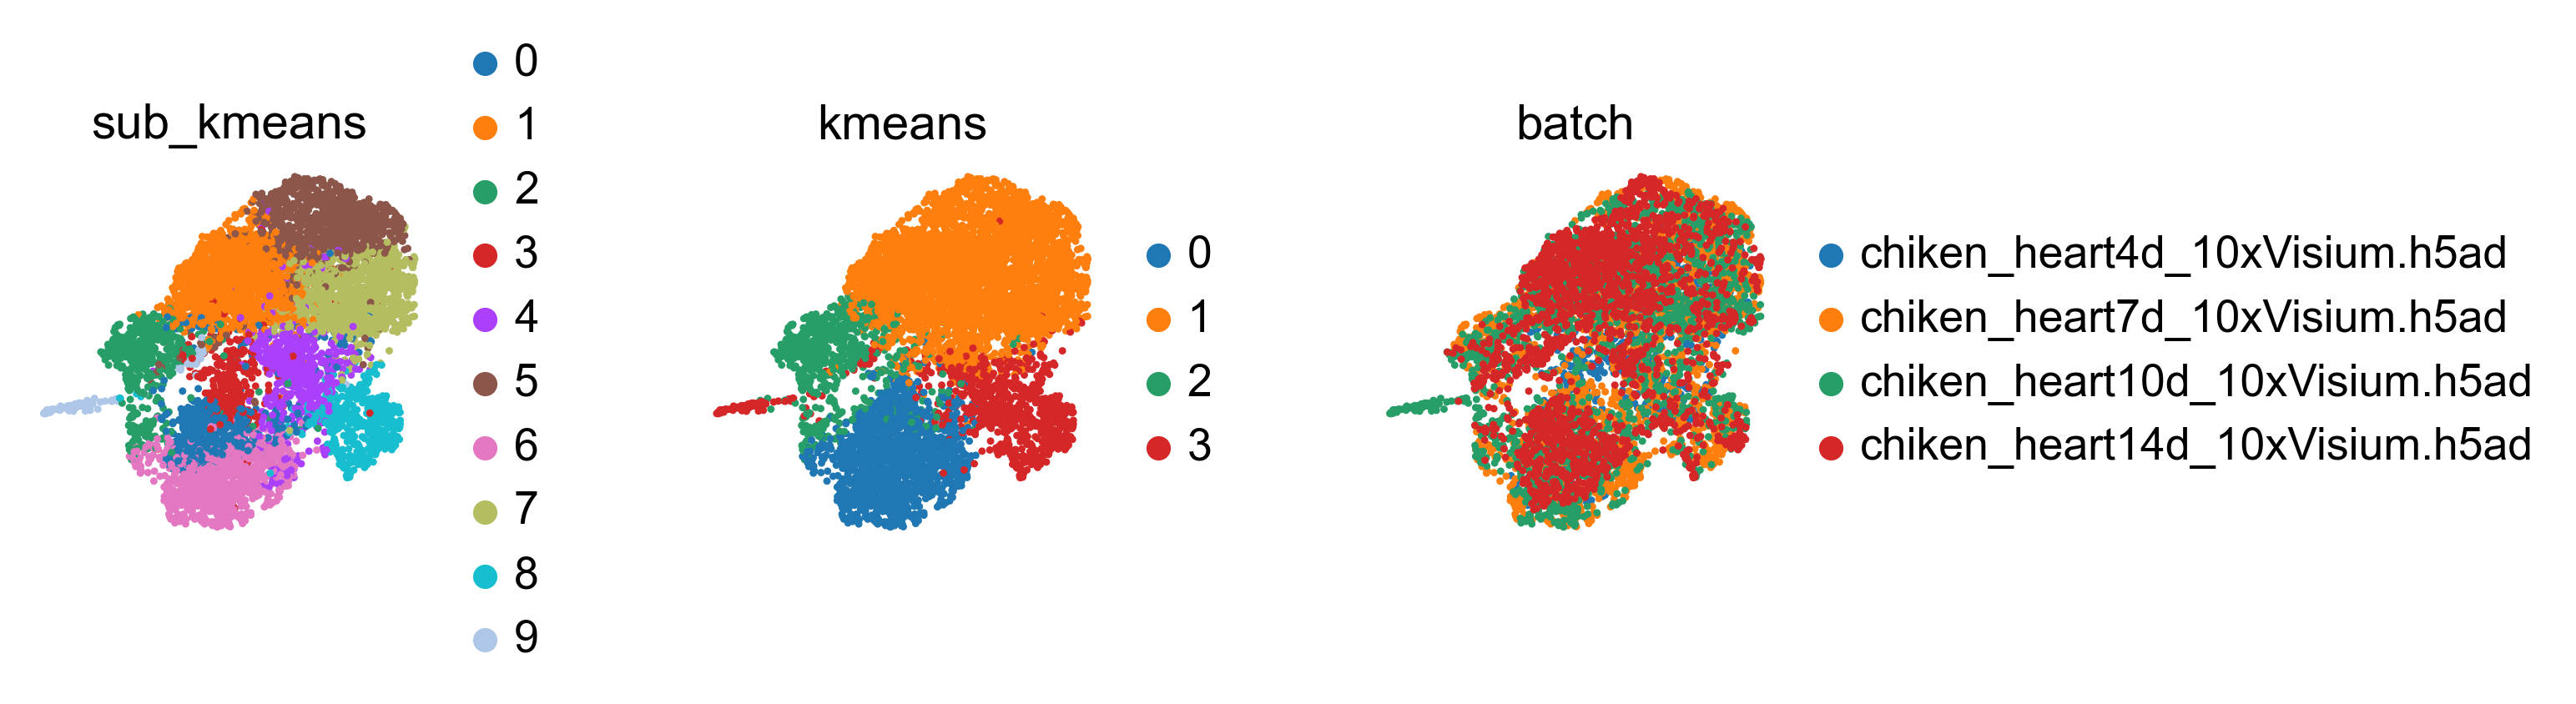

In [17]:
sc.pl.umap(adata_int, color=['sub_kmeans', 'kmeans', 'batch'], ncols=6, wspace=0.5)